#### Chain Using LangGraph

In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use that models in graph nodes
- how to bind tools to our LLm in chat models
- How to execute the tools call in our graph nodes

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [2]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Krish"))

for message in messages:
    message.pretty_print()



================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [3]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b")
results = llm_groq.invoke(messages)

In [4]:
results

AIMessage(content='<think>\nOkay, the user wants to learn Python. Let me think about how to structure this. First, I should start with the basics. Maybe an introduction to Python, setting up the environment. They might need to know about installing Python and choosing an IDE or text editor.\n\nNext, the core concepts. Variables, data types, control structures like loops and conditionals. Then functions and maybe modules. Oh, and error handling is important too. After that, data structures like lists, tuples, dictionaries, and sets. Object-oriented programming is a big part of Python, so classes and objects should be covered.\n\nThen moving to advanced topics. File handling, working with databases, web scraping with libraries like BeautifulSoup, data analysis with pandas, maybe some web development with Flask or Django. Also, GUI programming could be an option, but maybe that\'s more advanced. Automation scripts might be a good practical application for beginners.\n\nI should recommend 

In [5]:
results.response_metadata

{'token_usage': {'completion_tokens': 1622,
  'prompt_tokens': 54,
  'total_tokens': 1676,
  'completion_time': 4.602521196,
  'completion_tokens_details': None,
  'prompt_time': 0.00234398,
  'prompt_tokens_details': None,
  'queue_time': 0.006315631,
  'total_time': 4.604865176},
 'model_name': 'qwen/qwen3-32b',
 'system_fingerprint': 'fp_78ac7f3229',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [6]:
from langchain_core.tools import tool

@tool
def add(a:int, b:int)-> int:
    """Add a and b
    Args:
        a(int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [7]:
llm_groq

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022E6489DF70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022E649F29F0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
tools = [add]

In [9]:
## Binding tool with llm

llm_with_tools = llm_groq.bind_tools(tools)

tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2", name="Venkey")])

In [10]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'bakjabc8c',
  'type': 'tool_call'}]

#### Using messages as state

In [11]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

#### Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [12]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

#### Reducers with add_messages

In [13]:
initial_messages = [AIMessage(content=f"Please twll me how can i help", name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding", name="Krish"))
initial_messages

[AIMessage(content='Please twll me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish')]

In [14]:
ai_message=AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [15]:
### Reducers add_messages is to append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please twll me how can i help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='62a29054-cd09-465c-9762-01d4f1630d96', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish', id='8e58c62b-7f74-48f4-95b2-61d42ba17203'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='43d8b22f-dff1-4b5e-b7c0-ab7a98280da7', tool_calls=[], invalid_tool_calls=[])]

In [16]:
## chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

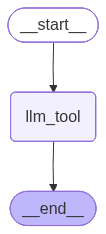

In [17]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (ywrkhg1z9)
 Call ID: ywrkhg1z9
  Args:
    a: 2
    b: 2


In [22]:
#tools=[add]

In [30]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder=StateGraph(State)

## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","llm_tool")
builder.add_edge("tools", END)



graph_builder = builder.compile()



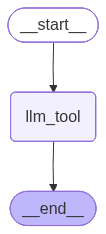

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 8"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (n18e781dx)
 Call ID: n18e781dx
  Args:
    a: 2
    b: 8


In [ ]:
messages=graph.invoke({"messages":"What Machine Learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What Machine Learning
================================== Ai Message ==================================

The provided tools are for performing the addition of two integers and cannot be used to explain the concept of machine learning. Let me know if you'd like me to provide an explanation without using the tools.

Machine learning is a subset of artificial intelligence (AI) that focuses on building systems that can learn from data. Instead of being explicitly programmed to perform a task, machine learning algorithms use statistical techniques to improve their performance through experience. Common applications include image recognition, natural language processing, recommendation systems, and more. Would you like to dive deeper into a specific aspect of machine learning?


In [34]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.messages import AnyMessage

@tool
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b

tools = [add]
llm_with_tools = llm_groq.bind_tools(tools)

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool")
builder.add_conditional_edges("llm_tool", tools_condition)
builder.add_edge("tools", "llm_tool")  # ✅ loop back

graph = builder.compile()


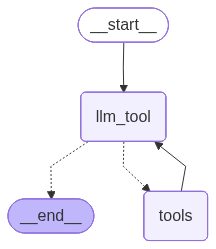

In [35]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (8dj16tqw8)
 Call ID: 8dj16tqw8
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================

The result of 2 plus 2 is **4**.


In [37]:
## invocation

messages=graph.invoke({"messages":"What is machine learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

The available functions do not include any tools for providing definitions or explanations. However, I can explain that **machine learning** is a subset of artificial intelligence (AI) that focuses on building systems that learn from data. Instead of being explicitly programmed to perform a task, these systems use algorithms to analyze data, identify patterns, and make decisions or predictions. For example, a machine learning model can be trained to recognize images of cats by analyzing thousands of labeled cat and non-cat images.
